In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

# Keep only the two useful columns and give them clear names
df = df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
print(df.shape)
print(df["label"].value_counts(normalize=True))
print("Duplicates:", df.duplicated().sum())

(5572, 2)
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64
Duplicates: 403


In [12]:
df = df.drop_duplicates()
print(df.shape)

(5169, 2)


In [13]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


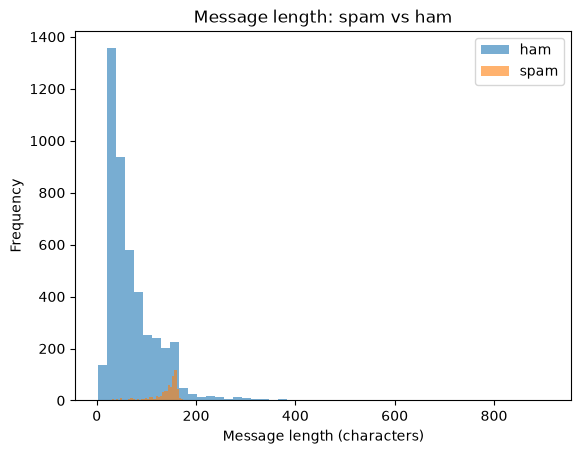

In [14]:
df["length"] = df["message"].str.len()
print(df.groupby("label")["length"].describe())

df[df["label"] == "ham"]["length"].plot.hist(bins=50, alpha=0.6, label="ham")
df[df["label"] == "spam"]["length"].plot.hist(bins=50, alpha=0.6, label="spam")
plt.xlabel("Message length (characters)")
plt.legend()
plt.title("Message length: spam vs ham")
plt.savefig("../images/length_distribution.png", bbox_inches="tight")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = (df["label"] == "spam").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(len(X_train), len(X_test))

4135 1034


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [37]:
models = { "Baseline (always ham)": DummyClassifier(strategy="most_frequent"),     "Naive Bayes": Pipeline([

        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", MultinomialNB()),
    ]),    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    })

results_df = pd.DataFrame(results).round(3)
results_df

,model,accuracy,precision,recall,f1
0,Baseline (always ham),0.873,0.000,0.000,0.000
1,Naive Bayes,0.966,0.990,0.740,0.847
2,Logistic Regression,0.976,0.921,0.885,0.903


Best model: Logistic Regression


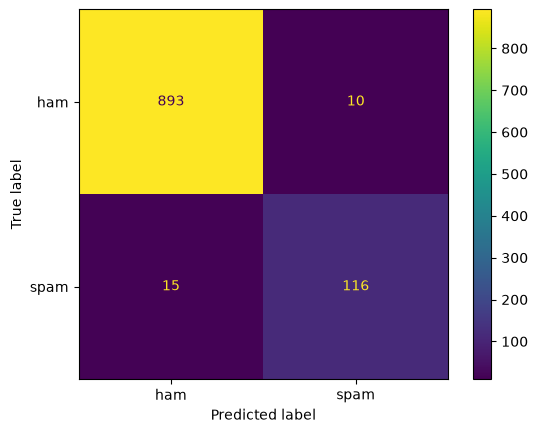

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
best_name = results_df.iloc[1:].sort_values("f1", ascending=False)["model"].iloc[0]

best_model = models[best_name]
print("Best model:", best_name)

ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=["ham", "spam"]
)

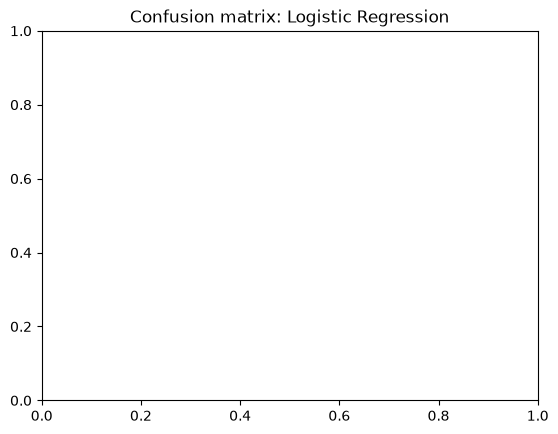

In [25]:
plt.title(f"Confusion matrix: {best_name}")
plt.savefig("../images/confusion_matrix.png", bbox_inches="tight")
plt.show()

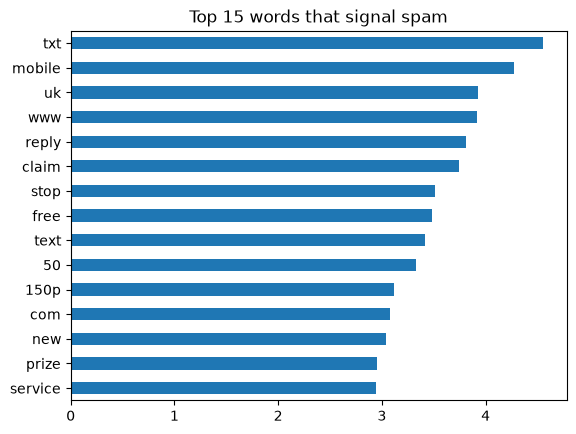

In [32]:
lr = models["Logistic Regression"]
words = lr.named_steps["tfidf"].get_feature_names_out()
weights = lr.named_steps["clf"].coef_[0]
top_spam_words = pd.Series(weights, index=words).sort_values(ascending=False).head(15)


top_spam_words.plot.barh()
plt.gca().invert_yaxis()
plt.title("Top 15 words that signal spam")
plt.savefig("../images/top_spam_words.png", bbox_inches="tight")
plt.show()

In [34]:
import joblib

tests = [
    "Congratulations! You've won a £1000 voucher. Text WIN to 80086 now",
    "Are we still meeting for lunch tomorrow?",
]
print(best_model.predict(tests))

[1 0]


In [35]:
joblib.dump(best_model, "../models/spam_model.joblib")

['../models/spam_model.joblib']